# 503: Temperature Contribution Analysis

This notebook calculates the contribution of different forcing components to temperature change
between peak warming year (from GSAT|ALL) and 2100.

**Components analysed:**
- ALL: Total warming
- CO2_NZCO2: CO2 warming if emissions held constant at net-zero level (ZEC proxy)
- CO2_Negative: Cooling from negative CO2 emissions (CO2 - CO2_NZCO2)
- NonCO2_GHG: Non-CO2 greenhouse gas contribution (GHG - CO2)
- Residual: Other forcings (ALL - GHG)

**Input:** Output from notebook 500 (contains `gsat_peak_year` per run)

**Note:** Only processes base scenarios (excludes _NZCO2 and _NZKyoto suffix scenarios)

In [10]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
from tqdm import tqdm

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
INDIVIDUAL_RUNS_DIR = OUTPUT_FOLDER / "individual_runs"

In [11]:
# Configuration
METRICS_500_FILE = OUTPUT_FOLDER / "500_gsat_metrics_2026-05-21_12-31.csv"
MANIFEST_FILE = OUTPUT_FOLDER / "individual_runs/manifests/2026-05-21_12-31_manifest.csv"

COMPONENTS = ["ALL", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

## Load Data

In [12]:
# Load 500 output and filter to base scenarios with ALL flag
metrics_500 = pd.read_csv(METRICS_500_FILE)
peak_years = metrics_500[
    (metrics_500["magicc_flag"] == "ALL") &
    (~metrics_500["scenario"].str.contains("_NZCO2|_NZKyoto", regex=True))
][["model", "scenario", "run_id", "gsat_peak_year"]].copy()

# Load manifest and create lookup dict
manifest = pd.read_csv(MANIFEST_FILE)
manifest["key"] = manifest["model"] + "|" + manifest["scenario"] + "|" + manifest["magicc_flag"]
file_lookup = manifest.set_index("key")["output_filename"].to_dict()

print(f"Peak years: {len(peak_years):,} runs, {peak_years.groupby(['model', 'scenario']).ngroups} scenarios")

Peak years: 410,400 runs, 684 scenarios


In [13]:
def load_timeseries(filepath: Path) -> pd.DataFrame:
    """Load timeseries with run_id index and integer year columns."""
    df = pd.read_csv(filepath)
    year_cols = [c for c in df.columns if c.isdigit()]
    ts = df.set_index("run_id")[year_cols].astype(float)
    ts.columns = ts.columns.astype(int)
    return ts


def extract_at_peak(ts: pd.DataFrame, peaks: pd.DataFrame) -> np.ndarray:
    """Vectorized extraction of values at peak years."""
    # Convert to numpy for fast indexing
    ts_arr = ts.values
    years = ts.columns.values
    run_ids = ts.index.values
    
    # Create mappings
    run_to_idx = {r: i for i, r in enumerate(run_ids)}
    year_to_idx = {y: i for i, y in enumerate(years)}
    
    # Extract values
    values = np.full(len(peaks), np.nan)
    for i, (run_id, year) in enumerate(zip(peaks["run_id"], peaks["gsat_peak_year"])):
        if run_id in run_to_idx and year in year_to_idx:
            values[i] = ts_arr[run_to_idx[run_id], year_to_idx[year]]
    return values

## Process Scenarios

In [14]:
scenarios = peak_years[["model", "scenario"]].drop_duplicates()
results = []

for model, scenario in tqdm(scenarios.values, desc="Processing"):
    # Get filenames from lookup
    files = {
        flag: file_lookup.get(f"{model}|{scenario}|{flag}")
        for flag in ["ALL", "CO2", "GHG"]
    }
    files["NZCO2"] = file_lookup.get(f"{model}|{scenario}_NZCO2|CO2")
    
    if not all(files[f] for f in ["ALL", "CO2", "GHG"]):
        continue
    
    # Load timeseries
    ts = {f: load_timeseries(INDIVIDUAL_RUNS_DIR / files[f]) for f in ["ALL", "CO2", "GHG"]}
    if files["NZCO2"]:
        ts["NZCO2"] = load_timeseries(INDIVIDUAL_RUNS_DIR / files["NZCO2"])
    
    # Derived components
    ts["NonCO2_GHG"] = ts["GHG"] - ts["CO2"]
    ts["Residual"] = ts["ALL"] - ts["GHG"]
    if files["NZCO2"]:
        ts["CO2_Negative"] = ts["CO2"] - ts["NZCO2"]
    
    # Get peaks for this scenario
    peaks = peak_years[(peak_years["model"] == model) & (peak_years["scenario"] == scenario)].copy()
    
    # Build result
    result = peaks[["model", "scenario", "run_id"]].copy()
    result["peak_year"] = peaks["gsat_peak_year"].values
    
    # Extract at peak and 2100
    for name, key in [("ALL", "ALL"), ("NonCO2_GHG", "NonCO2_GHG"), ("Residual", "Residual")]:
        result[f"GSAT|{name}|peak"] = extract_at_peak(ts[key], peaks)
        result[f"GSAT|{name}|2100"] = ts[key][2100].reindex(peaks["run_id"]).values
    
    if files["NZCO2"]:
        for name, key in [("CO2_NZCO2", "NZCO2"), ("CO2_Negative", "CO2_Negative")]:
            result[f"GSAT|{name}|peak"] = extract_at_peak(ts[key], peaks)
            result[f"GSAT|{name}|2100"] = ts[key][2100].reindex(peaks["run_id"]).values
    
    results.append(result)

metrics_df = pd.concat(results, ignore_index=True)
print(f"Processed {len(metrics_df):,} runs across {len(results)} scenarios")

Processing: 100%|██████████| 684/684 [01:01<00:00, 11.12it/s]

Processed 409,800 runs across 683 scenarios


## Calculate Deltas

In [15]:
# Calculate deltas (2100 - peak)
for comp in COMPONENTS:
    peak_col, y2100_col = f"GSAT|{comp}|peak", f"GSAT|{comp}|2100"
    if peak_col in metrics_df.columns:
        metrics_df[f"GSAT|{comp}|delta"] = metrics_df[y2100_col] - metrics_df[peak_col]

metrics_df.head()

,model,scenario,run_id,peak_year,GSAT|ALL|peak,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak,GSAT|NonCO2_GHG|2100,GSAT|Residual|peak,GSAT|Residual|2100,GSAT|CO2_NZCO2|peak,GSAT|CO2_NZCO2|2100,GSAT|CO2_Negative|peak,GSAT|CO2_Negative|2100,GSAT|ALL|delta,GSAT|CO2_NZCO2|delta,GSAT|CO2_Negative|delta,GSAT|NonCO2_GHG|delta,GSAT|Residual|delta
0,AIM/CGE 2.0,SSP1-19,0,2049,1.612907,1.411091,0.092336,-0.093244,-0.041236,0.057642,1.561807,1.512313,0.000000,-0.065621,-0.201816,-0.049494,-0.065621,-0.185580,0.098879
1,AIM/CGE 2.0,SSP1-19,1,2093,2.592601,2.577173,0.438947,0.419883,-0.822595,-0.819381,3.047597,3.072829,-0.071348,-0.096158,-0.015427,0.025233,-0.024810,-0.019064,0.003215
2,AIM/CGE 2.0,SSP1-19,2,2049,1.798363,1.577004,0.099817,-0.076595,0.046628,0.098229,1.651918,1.624423,0.000000,-0.069052,-0.221359,-0.027495,-0.069052,-0.176412,0.051601
3,AIM/CGE 2.0,SSP1-19,3,2038,1.379944,1.074082,0.098739,-0.197705,0.052872,0.165818,1.228334,1.158700,0.000000,-0.052731,-0.305862,-0.069634,-0.052731,-0.296443,0.112946
4,AIM/CGE 2.0,SSP1-19,4,2048,1.645092,1.396311,0.107123,-0.111821,-0.000573,0.090845,1.538542,1.480224,0.000000,-0.062936,-0.248781,-0.058318,-0.062936,-0.218945,0.091418


## Summary Statistics

In [16]:
# Aggregate by scenario (median only for simplicity)
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
stats = metrics_df.groupby(["model", "scenario"])[value_cols].median()
print(f"Statistics for {len(stats)} scenarios")
stats.round(3)

Statistics for 683 scenarios


GSAT|ALL|peak  GSAT|ALL|2100  \
model             scenario                                                
AIM/CGE 2.0       SSP1-19                          1.543          1.252   
                  SSP2-19                          1.513          1.133   
                  SSP2-26                          1.705          1.628   
                  SSP3-34                          2.076          2.068   
                  SSP4-26                          1.656          1.569   
...                                                  ...            ...   
WITCH-GLOBIOM 3.1 SSP4-19                          1.527          1.257   
WITCH-GLOBIOM 4.4 CD-LINKS-INDC2030i_1600          1.756          1.681   
                  CD-LINKS-NDC2030i_1000           1.607          1.359   
                  CD-LINKS-NPi2020_1000            1.591          1.472   
                  CD-LINKS-NPi2020_400             1.459          1.089   

                                           GSAT|NonCO2_GHG|peak  \
model             scenario                                        
AIM/CGE 2.0       SSP1-19                                 0.046   
                  SSP2-19                                 0.069   
                  SSP2-26                                 0.064   
                  SSP3-34                                 0.264   
                  SSP4-26                                 0.048   
...                                                         ...   
WITCH-GLOBIOM 3.1 SSP4-19                                 0.074   
WITCH-GLOBIOM 4.4 CD-LINKS-INDC2030i_1600                 0.014   
                  CD-LINKS-NDC2030i_1000                  0.078   
                  CD-LINKS-NPi2020_1000                   0.026   
                  CD-LINKS-NPi2020_400                    0.065   

                                           GSAT|NonCO2_GHG|2100  \
model             scenario                                        
AIM/CGE 2.0       SSP1-19                                -0.167   
                  SSP2-19                                -0.099   
                  SSP2-26                                 0.041   
                  SSP3-34                                 0.279   
                  SSP4-26                                 0.012   
...                                                         ...   
WITCH-GLOBIOM 3.1 SSP4-19                                -0.108   
WITCH-GLOBIOM 4.4 CD-LINKS-INDC2030i_1600                -0.067   
                  CD-LINKS-NDC2030i_1000                 -0.099   
                  CD-LINKS-NPi2020_1000                  -0.067   
                  CD-LINKS-NPi2020_400                   -0.135   

                                           GSAT|Residual|peak  \
model             scenario                                      
AIM/CGE 2.0       SSP1-19                               0.119   
                  SSP2-19                               0.094   
                  SSP2-26                               0.159   
                  SSP3-34                               0.143   
                  SSP4-26                               0.071   
...                                                       ...   
WITCH-GLOBIOM 3.1 SSP4-19                               0.082   
WITCH-GLOBIOM 4.4 CD-LINKS-INDC2030i_1600               0.083   
                  CD-LINKS-NDC2030i_1000                0.035   
                  CD-LINKS-NPi2020_1000                 0.071   
                  CD-LINKS-NPi2020_400                  0.030   

                                           GSAT|Residual|2100  \
model             scenario                                      
AIM/CGE 2.0       SSP1-19                               0.166   
                  SSP2-19                               0.133   
                  SSP2-26                               0.185   
                  SSP3-34                               0.141   
                  SSP4-26                               0.079   
...                   

In [17]:
# Summary of delta contributions
delta_cols = [f"GSAT|{c}|delta" for c in COMPONENTS if f"GSAT|{c}|delta" in metrics_df.columns]
delta_summary = stats[delta_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
delta_summary.index = [c.replace("GSAT|", "").replace("|delta", "") for c in delta_cols]
print("Component contributions (median delta, peak to 2100):")
delta_summary.round(3)

Component contributions (median delta, peak to 2100):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ALL,683.0,-0.148,0.106,-0.567,-0.348,-0.220,-0.118,-0.069,-0.017,0.000
CO2_NZCO2,683.0,-0.051,0.026,-0.165,-0.092,-0.068,-0.051,-0.032,-0.012,0.000
CO2_Negative,683.0,-0.068,0.071,-0.443,-0.202,-0.103,-0.048,-0.011,-0.001,0.021
NonCO2_GHG,683.0,-0.056,0.052,-0.260,-0.160,-0.084,-0.047,-0.019,0.005,0.091
Residual,683.0,0.021,0.027,-0.080,-0.009,0.002,0.014,0.035,0.075,0.114


## CO2_NZCO2 Decline vs Net-Zero Year

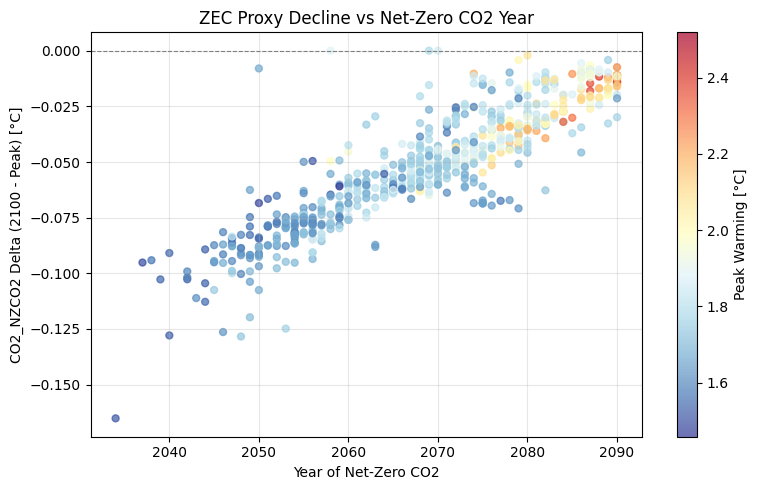

In [18]:
import matplotlib.pyplot as plt

# Load net-zero timings
netzero_timings = pd.read_csv(OUTPUT_FOLDER / "102_netzero_timings.csv")

# Merge with stats (median CO2_NZCO2 delta and peak warming per scenario)
plot_data = stats[["GSAT|CO2_NZCO2|delta", "GSAT|ALL|peak"]].reset_index().merge(
    netzero_timings[["model", "scenario", "year_netzero_co2"]],
    on=["model", "scenario"],
    how="inner"
).dropna()

# Scatter plot colored by peak warming
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    plot_data["year_netzero_co2"],
    plot_data["GSAT|CO2_NZCO2|delta"],
    c=plot_data["GSAT|ALL|peak"],
    cmap="RdYlBu_r",
    alpha=0.7,
    s=25
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Peak Warming [°C]")
ax.set_xlabel("Year of Net-Zero CO2")
ax.set_ylabel("CO2_NZCO2 Delta (2100 - Peak) [°C]")
ax.set_title("ZEC Proxy Decline vs Net-Zero CO2 Year")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()